# Eigenvalue-Warp Experiment: Leroux CAR vs Adaptive Precision P-spline SDM-CAR

The data are generated from a **true Leroux spatial field** on the true rook-lattice Laplacian,

$$
L_{\mathrm{true}}
=
U \Lambda U^\top,
$$

with true Leroux precision spectrum

$$
q_{\mathrm{true}}(\lambda)
=
\frac{(1-\rho_0)+\rho_0\lambda}{\tau_0^2}.
$$

Both fitted models are deliberately given a misspecified spectral operator. The eigenvectors are retained,

$$
U_{\mathrm{warp}} = U_{\mathrm{true}},
$$

while the positive Laplacian eigenvalues are warped according to

$$
\mu_1 = 0,
$$

and

$$
\mu_i
=
A
+
B\lambda_i
+
C\frac{\lambda_i^2}{\lambda_{\max}},
\qquad i\ge2.
$$

Here:

- $A$ controls an additive positive-mode shift;
- $B$ controls linear rescaling;
- $C$ controls nonlinear quadratic distortion.

The original affine-shift experiment is recovered when

$$
C=0.
$$

Setting

$$
A=0,\qquad B=1,\qquad C>0
$$

isolates **nonlinear spectral misspecification** while preserving the zero mode and eigenvectors.

The notebook compares:

1. **Leroux CAR on the warped operator** — the classical parametric baseline, whose precision remains affine in the supplied eigenvalues $\mu$.
2. **Adaptive positive-precision P-spline SDM-CAR on the same warped operator** — a flexible spectral model that can introduce nonlinear frequency-specific corrections.

The experiment separates three questions:

- **Family capacity:** can each model match the known target precision spectrum when the target is supplied directly?
- **Statistical recovery:** can each model recover the required spectral structure from a single noisy realization?
- **Prediction:** does the additional spectral flexibility improve reconstruction of held-out latent spatial effects?

## Why nonlinear warping creates Leroux misspecification

Under the true operator, Leroux precision is affine in $\lambda$,

$$
q_{\mathrm{true}}(\lambda)
=
\frac{(1-\rho_0)+\rho_0\lambda}{\tau_0^2}.
$$

For the purely quadratic experiment,

$$
A=0,
\qquad
B=1,
$$

the fitted eigenvalues satisfy

$$
\mu
=
\lambda
+
C\frac{\lambda^2}{\lambda_{\max}}.
$$

For $C>0$, the inverse relationship $\lambda=\lambda(\mu)$ is nonlinear. Therefore the target precision expressed in terms of the eigenvalues supplied to the fitted models becomes

$$
q_{\mathrm{target}}(\mu)
=
q_{\mathrm{true}}\!\left(\lambda(\mu)\right),
$$

which is generally nonlinear in $\mu$.

An ordinary Leroux model fitted on the warped operator is restricted to

$$
q_{\mathrm{Leroux}}(\mu)
=
\frac{(1-\rho)+\rho\mu}{\tau^2},
$$

which is affine in $\mu$.

Therefore, for $C>0$, no choice of $(\tau^2,\rho)$ can generally reproduce the nonlinear target precision exactly.

The adaptive P-spline SDM-CAR is not restricted to this affine-precision family. Its learned curvature allows it to absorb part of the nonlinear spectral distortion induced by the misspecified operator.

The direct spectrum-fitting experiments distinguish this **representational advantage** from the separate question of whether the likelihood contains enough information to recover that flexibility from finite noisy data.

## 1. Imports and project path

In [142]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import torch

from IPython.display import display

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    AdaptivePrecisionPSplineFullVI,
    PositivePrecisionPSplineFullVI
)
from sdmcar.models_holdout import SpectralCAR_HoldoutVI

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

print("Project root:", ROOT)
print("Device:", DEVICE)


Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu


## 2. Locked configuration

In [ ]:
SEED = 111

N_ROWS = 10
N_COLS = 10
N = N_ROWS * N_COLS

TAU2_TRUE = 0.70
RHO_TRUE = 0.92
BETA_TRUE = 0.0
SIGMA2_TRUE = 0.15

HOLDOUT_SIDE = 10

# Change only A ----------------------------------------------------------------------------------------------------------------
AFFINE_SHIFT_A = 0.0
AFFINE_SCALE_B = 1.00

# Nonlinear warp strength -------------------------------------------------------------------------------------------------------
NONLINEAR_QUAD_C = 0

FIX_SIGMA2 = True
NUM_MC = 8
PRED_MC = 512
GRAD_CLIP = 10.0

# Likelihood-based VI.
LEROUX_ITERS = 3000
LEROUX_LR = 1e-3

PSPLINE_ITERS = 6000
PSPLINE_LR = 3e-4

# Direct target-spectrum fits.
DIRECT_LEROUX_ITERS = 3000
DIRECT_LEROUX_LR = 1e-2

DIRECT_PSPLINE_ITERS = 4000
DIRECT_PSPLINE_LR = 2e-2

# Fixed, truth-independent initializations used for every A and seed.
INIT_LEROUX_TAU2 = 0.50
INIT_LEROUX_RHO = 0.80

INIT_Q_LEFT = 0.20
INIT_Q_RIGHT = 20.0

CURVATURE_PRIOR_STD = 0.50

PSPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 4,
    "prior_std_log_q": 3.0,
    "prior_std_d2": CURVATURE_PRIOR_STD,
    "log_std_log_q": -3.0,
    "log_std_d2": -3.0,
    "init_d2": 0.0,
    "log_q_min": -20.0,
    "log_q_max": 20.0,
}

ADAPTIVE_PSPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 4,
    "prior_std_log_q": 3.0,
    "global_scale_d2": CURVATURE_PRIOR_STD, 
    "prior_std_log_lambda": 2.0, 
    "mu_log_lambda_init": 0.0,
    "log_std_log_lambda": -3.0,
    "log_std_log_q": -3.0,
    "log_std_d2": -3.0,
    "init_d2": 0.0,
    "log_q_min": -20.0,
    "log_q_max": 20.0,
}



np.random.seed(SEED)
torch.manual_seed(SEED)

A_CRITICAL = (1.0 - RHO_TRUE) / RHO_TRUE

print("Nodes:", N)
print("Seed:", SEED)
print("Affine shift A:", AFFINE_SHIFT_A)
print("Affine scale B:", AFFINE_SCALE_B)
print("Curvature prior SD:", PSPLINE_KWARGS["prior_std_d2"])
print(f"Theoretical Leroux boundary: {A_CRITICAL:.6f}")
print(
    "Regime:",
    "inside exact Leroux family"
    if AFFINE_SHIFT_A < A_CRITICAL
    else "outside exact Leroux family",
)


Nodes: 100
Seed: 111
Affine shift A: 0.0
Affine scale B: 1.0
Curvature prior SD: 0.5
Theoretical Leroux boundary: 0.086957
Regime: inside exact Leroux family


## 3. True rook graph and warped eigenvalues

In [170]:
def node_index(row, col):
    return row * N_COLS + col


def build_rook_adjacency():
    W = np.zeros((N, N), dtype=float)

    for row in range(N_ROWS):
        for col in range(N_COLS):
            i = node_index(row, col)

            if col + 1 < N_COLS:
                j = node_index(row, col + 1)
                W[i, j] = W[j, i] = 1.0

            if row + 1 < N_ROWS:
                j = node_index(row + 1, col)
                W[i, j] = W[j, i] = 1.0

    np.fill_diagonal(W, 0.0)
    return W


def graph_laplacian(W):
    degree = W.sum(axis=1)
    L = np.diag(degree) - W
    return 0.5 * (L + L.T)


# def affine_shift_positive_modes(
#     lam,
#     shift,
#     scale=1.0,
#     zero_tolerance=1e-8,
# ):
#     if shift < 0.0:
#         raise ValueError("shift must be nonnegative.")
#     if scale <= 0.0:
#         raise ValueError("scale must be positive.")

#     lam = np.asarray(lam, dtype=float)
#     warped = np.zeros_like(lam)
#     positive = lam > zero_tolerance
#     warped[positive] = shift + scale * lam[positive]
#     return warped

def nonlinear_warp_positive_modes(
    lam,
    shift,
    scale=1.0,
    quad_strength=0.0,
    zero_tolerance=1e-8,
):
    """
    Warp positive Laplacian eigenvalues as

        mu = shift
             + scale * lambda
             + quad_strength * lambda^2 / lambda_max

    while preserving the zero eigenvalue exactly.

    quad_strength = 0 gives the original affine warp.
    """

    if shift < 0.0:
        raise ValueError("shift must be nonnegative.")

    if scale <= 0.0:
        raise ValueError("scale must be positive.")

    if quad_strength < 0.0:
        raise ValueError(
            "For this initial experiment, quad_strength must be nonnegative."
        )

    lam = np.asarray(lam, dtype=float)

    warped = np.zeros_like(lam)

    positive = lam > zero_tolerance

    lam_max = lam[positive].max()

    lam_pos = lam[positive]

    warped[positive] = (
        shift
        + scale * lam_pos
        + quad_strength * (lam_pos**2 / lam_max)
    )

    return warped

W_true = build_rook_adjacency()
L_true = graph_laplacian(W_true)

lam_true, U_true = np.linalg.eigh(L_true)
lam_true = np.clip(lam_true, 0.0, None)

# lam_warp = affine_shift_positive_modes(
#     lam_true,
#     shift=AFFINE_SHIFT_A,
#     scale=AFFINE_SCALE_B,
# )

lam_warp = nonlinear_warp_positive_modes(
    lam_true,
    shift=AFFINE_SHIFT_A,
    scale=AFFINE_SCALE_B,
    quad_strength=NONLINEAR_QUAD_C,
)


# Controlled experiment: eigenvectors remain correct.
U_warp = U_true.copy()

positive_true_mask = lam_true > 1e-8
positive_warp_mask = lam_warp > 1e-8

print("Undirected edges:", np.count_nonzero(W_true) // 2)
print("True eigenvalue range:", (lam_true.min(), lam_true.max()))
print("Warped eigenvalue range:", (lam_warp.min(), lam_warp.max()))
print(
    "Smallest positive true eigenvalue:",
    lam_true[positive_true_mask].min(),
)
print(
    "Smallest positive warped eigenvalue:",
    lam_warp[positive_warp_mask].min(),
)

Undirected edges: 180
True eigenvalue range: (np.float64(0.0), np.float64(7.804226065180614))
Warped eigenvalue range: (np.float64(0.0), np.float64(31.216904260722455))
Smallest positive true eigenvalue: 0.09788696740969097
Smallest positive warped eigenvalue: 0.10157030191665113


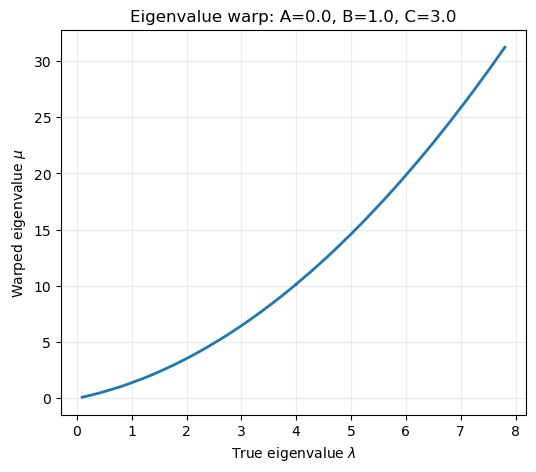

In [171]:
plt.figure(figsize=(6, 5))

plt.plot(
    lam_true[positive_true_mask],
    lam_warp[positive_true_mask],
    lw=2,
)

plt.xlabel(r"True eigenvalue $\lambda$")
plt.ylabel(r"Warped eigenvalue $\mu$")
plt.title(
    rf"Eigenvalue warp: A={AFFINE_SHIFT_A}, "
    rf"B={AFFINE_SCALE_B}, C={NONLINEAR_QUAD_C}"
)

plt.grid(alpha=0.25)
plt.show()

## 4. Simulate one Leroux spatial field

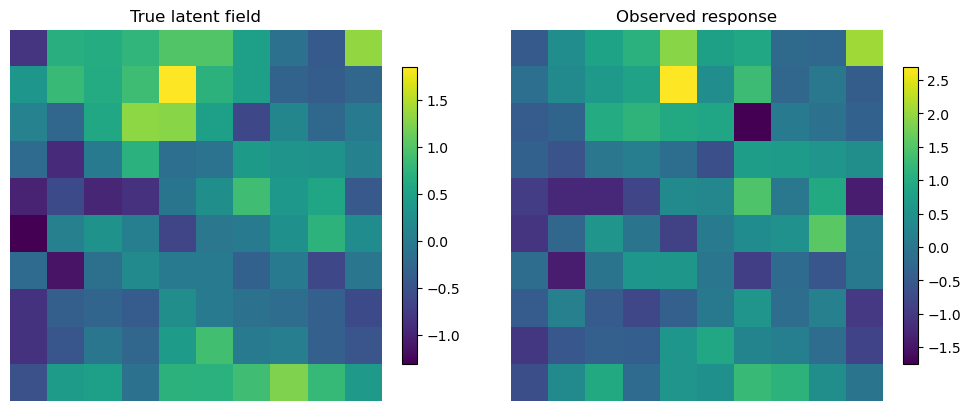

In [172]:
rng = np.random.default_rng(SEED)

# True covariance spectrum in the true eigenbasis.
F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = U_true @ (
    np.sqrt(F_true)
    * rng.normal(size=N)
)

eta_true = BETA_TRUE + phi_true

y = eta_true + rng.normal(
    loc=0.0,
    scale=np.sqrt(SIGMA2_TRUE),
    size=N,
)

# Because U_warp = U_true, this is also the target modal
# covariance under the warped operator ordering.
target_covariance = F_true.copy()
target_precision = 1.0 / target_covariance

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

image_0 = axes[0].imshow(
    eta_true.reshape(N_ROWS, N_COLS)
)
axes[0].set_title("True latent field")
axes[0].axis("off")
fig.colorbar(image_0, ax=axes[0], shrink=0.8)

image_1 = axes[1].imshow(
    y.reshape(N_ROWS, N_COLS)
)
axes[1].set_title("Observed response")
axes[1].axis("off")
fig.colorbar(image_1, ax=axes[1], shrink=0.8)

plt.show()

## 5. Holdout block and tensors

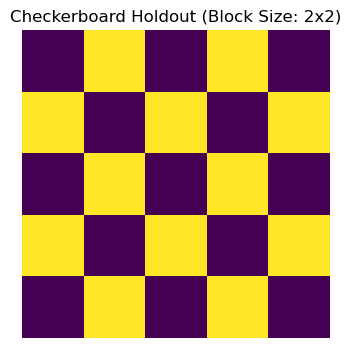

Training nodes: 52
Held-out nodes: 48


In [173]:
def checkerboard_block_mask(n_rows, n_cols, block_size=2):
    """
    Creates a spatial checkerboard mask.
    True indicates the node is held out (masked).
    """
    mask = np.zeros((n_rows, n_cols), dtype=bool)

    for r in range(n_rows):
        for c in range(n_cols):
            # Alternate spatial blocks
            if (r // block_size + c // block_size) % 2 == 1:
                mask[r, c] = True

    return mask.ravel()


def graph_tensors(lam, U):
    return (
        torch.tensor(
            np.clip(lam, 0.0, None),
            dtype=torch.double,
            device=DEVICE,
        ),
        torch.tensor(
            U,
            dtype=torch.double,
            device=DEVICE,
        ),
    )


# ---------------------------------------------------------
# Apply checkerboard holdout mask
# ---------------------------------------------------------

BLOCK_SIZE = 2

test_mask = checkerboard_block_mask(
    N_ROWS,
    N_COLS,
    block_size=BLOCK_SIZE,
)

train_mask = ~test_mask


# ---------------------------------------------------------
# PyTorch tensors for VI pipeline
# ---------------------------------------------------------

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=DEVICE,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

# Save actual held-out values for later evaluation
y_test_t = y_all_t[is_holdout_t].clone()

# Hide held-out observations from model fitting
y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan


# ---------------------------------------------------------
# Prior
# ---------------------------------------------------------

prior_V0 = 10.0 * torch.eye(
    1,
    dtype=torch.double,
    device=DEVICE,
)


# ---------------------------------------------------------
# Graph quantities
# ---------------------------------------------------------

lam_warp_t, U_warp_t = graph_tensors(
    lam_warp,
    U_warp,
)


# ---------------------------------------------------------
# Visualize holdout pattern
# ---------------------------------------------------------

plt.figure(figsize=(4.5, 4))
plt.imshow(
    test_mask.reshape(N_ROWS, N_COLS)
)
plt.title(
    f"Checkerboard Holdout "
    f"(Block Size: {BLOCK_SIZE}x{BLOCK_SIZE})"
)
plt.axis("off")
plt.show()


print("Training nodes:", int(train_mask.sum()))
print("Held-out nodes:", int(test_mask.sum()))

## 6. Filter factories

Both likelihood fits use the **same warped eigenvalues and eigenvectors**. The only difference is the spectral family.

The Leroux initialization below is fixed and truth-independent. The project `LerouxCARFilterFullVI` itself is otherwise used unchanged.


In [174]:
def rho_to_raw(rho, rho_eps=1e-4):
    """Invert rho = (1-rho_eps) * sigmoid(rho_raw)."""
    probability = rho / (1.0 - rho_eps)

    if not 0.0 < probability < 1.0:
        raise ValueError(
            "rho is incompatible with rho_eps."
        )

    return math.log(
        probability
        / (1.0 - probability)
    )


def make_leroux_filter():
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(INIT_LEROUX_TAU2),
        log_std_log_tau2=-3.0,
        mu_rho_raw=rho_to_raw(INIT_LEROUX_RHO),
        log_std_rho_raw=-3.0,
        fixed_rho=None,
        rho_eps=1e-4,
    ).to(DEVICE)


# Update your factory function
def make_precision_spline_filter(lam_t):
    return AdaptivePrecisionPSplineFullVI(
        lam_max=float(lam_t.max().item()),
        mu_log_q_left=math.log(INIT_Q_LEFT),
        mu_log_q_right=math.log(INIT_Q_RIGHT),
        **ADAPTIVE_PSPLINE_KWARGS,
    ).to(DEVICE)

# def make_precision_spline_filter(lam_t):
#     return PositivePrecisionPSplineFullVI(
#         lam_max=float(lam_t.max().item()),
#         mu_log_q_left=math.log(INIT_Q_LEFT),
#         mu_log_q_right=math.log(INIT_Q_RIGHT),
#         **PSPLINE_KWARGS,
#     ).to(DEVICE)

leroux_check = make_leroux_filter()
filter_check = make_precision_spline_filter(lam_warp_t)

print("Leroux initialization:")
tau2_init, rho_init_vec = leroux_check.mean_params()
print("  tau2 =", float(tau2_init.cpu()))
print("  rho  =", float(rho_init_vec[0].cpu()))

print("\nP-spline structure:")
print("  basis functions J:", filter_check.J)
print("  second-difference parameters K:", filter_check.K)


Leroux initialization:
  tau2 = 0.5
  rho  = 0.8

P-spline structure:
  basis functions J: 8
  second-difference parameters K: 6


## 7. Direct representational-capacity check

These fits see the **known target precision** and therefore do **not** measure statistical recovery.

They answer two separate family-capacity questions:

- How closely can an ordinary Leroux spectrum on the warped eigenvalues reproduce the target?
- How closely can the positive-precision P-spline reproduce the same target?

For the P-spline, only the endpoint means and second-difference means are optimized. For Leroux, only the variational means of \(\log\tau^2\) and \(\rho_{\rm raw}\) are optimized.


In [175]:
def direct_filter_theta(filter_module):
    theta = {
        "log_q_left": filter_module.mu_log_q_endpoints[0:1],
        "log_q_right": filter_module.mu_log_q_endpoints[1:2],
    }

    for j in range(filter_module.K):
        theta[f"d2_{j}_raw"] = filter_module.mu_d2[j:j + 1]

    return theta


def direct_leroux_theta(filter_module):
    return {
        "log_tau2": filter_module.mu_log_tau2.reshape(1),
        "rho_raw": filter_module.mu_rho_raw.reshape(1),
    }


def log_spectrum_rmse(estimated, target, mask=None):
    estimated = np.asarray(estimated, dtype=float)
    target = np.asarray(target, dtype=float)

    if mask is not None:
        estimated = estimated[mask]
        target = target[mask]

    estimated = np.clip(estimated, 1e-12, None)
    target = np.clip(target, 1e-12, None)

    return float(
        np.sqrt(
            np.mean(
                (
                    np.log(estimated)
                    - np.log(target)
                ) ** 2
            )
        )
    )


q_target_t = torch.tensor(
    target_precision,
    dtype=torch.double,
    device=DEVICE,
)

# ---------------------------------------------------------
# Direct Leroux target fit
# ---------------------------------------------------------
direct_leroux = make_leroux_filter()

direct_leroux_optimizer = torch.optim.Adam(
    [
        direct_leroux.mu_log_tau2,
        direct_leroux.mu_rho_raw,
    ],
    lr=DIRECT_LEROUX_LR,
)

direct_leroux_loss_history = []

for iteration in range(1, DIRECT_LEROUX_ITERS + 1):
    direct_leroux_optimizer.zero_grad(set_to_none=True)

    theta_direct_leroux = direct_leroux_theta(
        direct_leroux
    )

    F_direct_leroux_t = direct_leroux.spectrum(
        lam_warp_t,
        theta_direct_leroux,
    )

    q_direct_leroux_t = 1.0 / F_direct_leroux_t.clamp_min(
        1e-12
    )

    direct_leroux_loss = torch.mean(
        (
            torch.log(q_direct_leroux_t)
            - torch.log(q_target_t)
        ) ** 2
    )

    direct_leroux_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            direct_leroux.mu_log_tau2,
            direct_leroux.mu_rho_raw,
        ],
        max_norm=10.0,
    )

    direct_leroux_optimizer.step()

    direct_leroux_loss_history.append(
        float(direct_leroux_loss.detach().cpu())
    )

    if iteration == 1 or iteration % 500 == 0:
        print(
            f"Direct Leroux {iteration:4d} | "
            f"log-MSE={direct_leroux_loss_history[-1]:.8f}"
        )


with torch.no_grad():
    theta_direct_leroux = direct_leroux_theta(
        direct_leroux
    )

    F_direct_leroux = (
        direct_leroux
        .spectrum(
            lam_warp_t,
            theta_direct_leroux,
        )
        .detach()
        .cpu()
        .numpy()
    )

q_direct_leroux = 1.0 / np.clip(
    F_direct_leroux,
    1e-12,
    None,
)

direct_leroux_tau2, direct_leroux_rho_vec = (
    direct_leroux.mean_params()
)

# ---------------------------------------------------------
# Direct P-spline target fit
# ---------------------------------------------------------
direct_filter = make_precision_spline_filter(
    lam_warp_t
)

direct_pspline_optimizer = torch.optim.Adam(
    [
        direct_filter.mu_log_q_endpoints,
        direct_filter.mu_d2,
    ],
    lr=DIRECT_PSPLINE_LR,
)

direct_pspline_loss_history = []

for iteration in range(1, DIRECT_PSPLINE_ITERS + 1):
    direct_pspline_optimizer.zero_grad(set_to_none=True)

    theta_direct = direct_filter_theta(direct_filter)

    q_direct_t = (
        direct_filter.precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
    )

    direct_pspline_loss = torch.mean(
        (
            torch.log(q_direct_t)
            - torch.log(q_target_t)
        ) ** 2
    )

    direct_pspline_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            direct_filter.mu_log_q_endpoints,
            direct_filter.mu_d2,
        ],
        max_norm=10.0,
    )

    direct_pspline_optimizer.step()

    direct_pspline_loss_history.append(
        float(direct_pspline_loss.detach().cpu())
    )

    if iteration == 1 or iteration % 500 == 0:
        print(
            f"Direct P-spline {iteration:4d} | "
            f"log-MSE={direct_pspline_loss_history[-1]:.8f}"
        )


with torch.no_grad():
    theta_direct = direct_filter_theta(direct_filter)

    q_direct_fit = (
        direct_filter
        .precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
        .detach()
        .cpu()
        .numpy()
    )

F_direct_fit = 1.0 / np.clip(
    q_direct_fit,
    1e-12,
    None,
)

direct_summary = direct_filter.shrinkage_summary()

left = np.argmin(lam_warp)
right = np.argmax(lam_warp)

direct_metrics = pd.DataFrame(
    [
        {
            "model": "Direct Leroux",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_leroux[left],
            "q_right": q_direct_leroux[right],
            "d2_l2": np.nan,
        },
        {
            "model": "Direct P-spline",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_fit[left],
            "q_right": q_direct_fit[right],
            "d2_l2": float(
                direct_summary["d2_l2"].cpu()
            ),
        },
        {
            "model": "Target",
            "log_spectrum_rmse_all": 0.0,
            "log_spectrum_rmse_positive": 0.0,
            "q_left": target_precision[left],
            "q_right": target_precision[right],
            "d2_l2": np.nan,
        },
    ]
)

display(direct_metrics)

print("Direct Leroux parameters:")
print(
    "  tau2 =",
    float(direct_leroux_tau2.detach().cpu()),
)
print(
    "  rho  =",
    float(direct_leroux_rho_vec[0].detach().cpu()),
)


Direct Leroux    1 | log-MSE=1.19641392


Direct Leroux  500 | log-MSE=0.05944976
Direct Leroux 1000 | log-MSE=0.05943568
Direct Leroux 1500 | log-MSE=0.05943565
Direct Leroux 2000 | log-MSE=0.05943565
Direct Leroux 2500 | log-MSE=0.05943565
Direct Leroux 3000 | log-MSE=0.05943565
Direct P-spline    1 | log-MSE=0.09397018
Direct P-spline  500 | log-MSE=0.00060534
Direct P-spline 1000 | log-MSE=0.00035187
Direct P-spline 1500 | log-MSE=0.00033858
Direct P-spline 2000 | log-MSE=0.00033718
Direct P-spline 2500 | log-MSE=0.00033704
Direct P-spline 3000 | log-MSE=0.00033703
Direct P-spline 3500 | log-MSE=0.00033703
Direct P-spline 4000 | log-MSE=0.00033703


,model,log_spectrum_rmse_all,log_spectrum_rmse_positive,q_left,q_right,d2_l2
0,Direct Leroux,0.243794,0.221781,0.322171,15.943099,NaN
1,Direct P-spline,0.018358,0.016975,0.122812,10.402336,1.710623
2,Target,0.000000,0.000000,0.114286,10.371269,NaN


Direct Leroux parameters:
  tau2 = 1.2157014306834837
  rho  = 0.6083366002013366


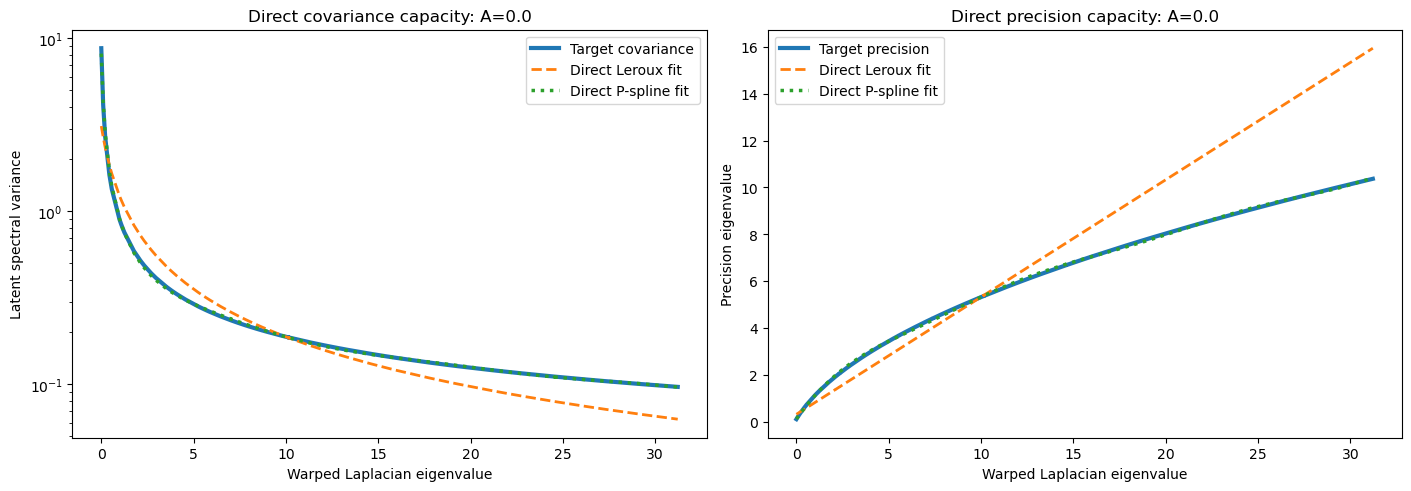

In [176]:
order = np.argsort(lam_warp)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_covariance[order],
    linewidth=3,
    label="Target covariance",
)
axes[0].plot(
    lam_warp[order],
    F_direct_leroux[order],
    linestyle="--",
    linewidth=2,
    label="Direct Leroux fit",
)
axes[0].plot(
    lam_warp[order],
    F_direct_fit[order],
    linestyle=":",
    linewidth=2.5,
    label="Direct P-spline fit",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Warped Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(
    f"Direct covariance capacity: A={AFFINE_SHIFT_A}"
)
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)
axes[1].plot(
    lam_warp[order],
    q_direct_leroux[order],
    linestyle="--",
    linewidth=2,
    label="Direct Leroux fit",
)
axes[1].plot(
    lam_warp[order],
    q_direct_fit[order],
    linestyle=":",
    linewidth=2.5,
    label="Direct P-spline fit",
)
axes[1].set_xlabel("Warped Laplacian eigenvalue")
axes[1].set_ylabel("Precision eigenvalue")
axes[1].set_title(
    f"Direct precision capacity: A={AFFINE_SHIFT_A}"
)
axes[1].legend()

plt.show()


## 8. Likelihood-based Leroux and P-spline fits

Both models now use only the training observations and the **same warped operator**. This is the comparison that matters for the misspecification experiment.

No oracle model is fitted here: Leroux and P-spline both receive exactly the same

$$
(\mu, U_{\rm warp}).
$$


In [177]:
def fit_spectral_vi(
    *,
    label,
    lam_t,
    U_t,
    filter_module,
    iterations,
    learning_rate,
    seed,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=(
            SIGMA2_TRUE if FIX_SIGMA2 else None
        ),
        jitter=1e-8,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    history = []

    for iteration in range(1, iterations + 1):
        optimizer.zero_grad(set_to_none=True)

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite {label} loss "
                f"at iteration {iteration}."
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        optimizer.step()
        history.append(float(elbo.detach().cpu()))

        if iteration % 500 == 0:
            recent = float(
                np.mean(history[-100:])
            )
            print(
                f"{label}: {iteration}/{iterations}, "
                f"recent ELBO={recent:.3f}"
            )

    torch.manual_seed(seed + 10_000)

    prediction = model.predict_vi_mc(
        num_mc=PRED_MC
    )

    metrics = model.score_predictions(
        y_test=y_test_t,
        prediction=prediction,
    )

    return {
        "label": label,
        "model": model,
        "prediction": prediction,
        "metrics": metrics,
        "history": history,
        "lam_t": lam_t,
        "U_t": U_t,
    }


leroux_result = fit_spectral_vi(
    label="Leroux VI",
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

pspline_result = fit_spectral_vi(
    label="P-spline VI",
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    filter_module=make_precision_spline_filter(
        lam_warp_t
    ),
    iterations=PSPLINE_ITERS,
    learning_rate=PSPLINE_LR,
    seed=SEED,
)

print("Both likelihood fits complete.")


Leroux VI: 500/3000, recent ELBO=-30.697
Leroux VI: 1000/3000, recent ELBO=-23.878
Leroux VI: 1500/3000, recent ELBO=-21.818
Leroux VI: 2000/3000, recent ELBO=-21.281
Leroux VI: 2500/3000, recent ELBO=-21.092
Leroux VI: 3000/3000, recent ELBO=-21.032
P-spline VI: 500/6000, recent ELBO=-54.384
P-spline VI: 1000/6000, recent ELBO=-51.295
P-spline VI: 1500/6000, recent ELBO=-48.467
P-spline VI: 2000/6000, recent ELBO=-45.794
P-spline VI: 2500/6000, recent ELBO=-43.379
P-spline VI: 3000/6000, recent ELBO=-41.200
P-spline VI: 3500/6000, recent ELBO=-39.436
P-spline VI: 4000/6000, recent ELBO=-38.021
P-spline VI: 4500/6000, recent ELBO=-36.795
P-spline VI: 5000/6000, recent ELBO=-35.752
P-spline VI: 5500/6000, recent ELBO=-34.782
P-spline VI: 6000/6000, recent ELBO=-33.853
Both likelihood fits complete.


## 9. Prediction metrics

In [178]:
leroux_prediction_mean = (
    leroux_result["prediction"]["mean"]
    .detach()
    .cpu()
    .numpy()
)

pspline_prediction_mean = (
    pspline_result["prediction"]["mean"]
    .detach()
    .cpu()
    .numpy()
)


def latent_holdout_rmse(prediction_mean):
    return float(
        np.sqrt(
            np.mean(
                (
                    prediction_mean
                    - eta_true[test_mask]
                ) ** 2
            )
        )
    )


prediction_results = pd.DataFrame(
    [
        {
            "model": "Leroux CAR",
            "A": AFFINE_SHIFT_A,
            "test_y_rmse": float(
                leroux_result["metrics"]["rmse"]
            ),
            "test_y_mae": float(
                leroux_result["metrics"]["mae"]
            ),
            "test_eta_rmse": latent_holdout_rmse(
                leroux_prediction_mean
            ),
        },
        {
            "model": "Precision P-spline SDM-CAR",
            "A": AFFINE_SHIFT_A,
            "test_y_rmse": float(
                pspline_result["metrics"]["rmse"]
            ),
            "test_y_mae": float(
                pspline_result["metrics"]["mae"]
            ),
            "test_eta_rmse": latent_holdout_rmse(
                pspline_prediction_mean
            ),
        },
    ]
)

display(prediction_results)

eta_gain = (
    prediction_results.loc[
        prediction_results["model"] == "Leroux CAR",
        "test_eta_rmse",
    ].iloc[0]
    -
    prediction_results.loc[
        prediction_results["model"]
        == "Precision P-spline SDM-CAR",
        "test_eta_rmse",
    ].iloc[0]
)

print(
    "Latent-RMSE gain (Leroux - P-spline):",
    f"{eta_gain:.6f}",
)
print("Positive gain favors the P-spline.")


,model,A,test_y_rmse,test_y_mae,test_eta_rmse
0,Leroux CAR,0.0,0.602350,0.470051,0.432178
1,Precision P-spline SDM-CAR,0.0,0.605829,0.474282,0.435742


Latent-RMSE gain (Leroux - P-spline): -0.003564
Positive gain favors the P-spline.


## 10. Posterior spectra, Leroux parameters, and P-spline curvature

In [179]:
@torch.no_grad()
def plugin_spectrum(result):
    theta_mean = (
        result["model"]
        .filter
        .mean_unconstrained()
    )

    return (
        result["model"]
        .filter
        .spectrum(
            result["lam_t"],
            theta_mean,
        )
        .detach()
        .cpu()
        .numpy()
    )


@torch.no_grad()
def posterior_spectrum_precision_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_000,
):
    """
    Joint Monte Carlo summaries of covariance spectrum F
    and precision spectrum q=1/F.

    This reports E[F(theta)] and E[q(theta)] separately.
    In particular, E[q] is not computed as 1/E[F].
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie between 0 and 1."
        )

    torch.manual_seed(seed)
    F_draws = []

    for _ in range(draws):
        theta = (
            result["model"]
            .filter
            .sample_unconstrained()
        )

        F = (
            result["model"]
            .filter
            .spectrum(
                result["lam_t"],
                theta,
            )
            .clamp_min(1e-12)
        )

        F_draws.append(F)

    F_draws = torch.stack(
        F_draws,
        dim=0,
    )
    q_draws = 1.0 / F_draws

    tail = (1.0 - credible_level) / 2.0

    def summarize(draws_t):
        return {
            "mean": draws_t.mean(dim=0),
            "lower": torch.quantile(
                draws_t,
                tail,
                dim=0,
            ),
            "upper": torch.quantile(
                draws_t,
                1.0 - tail,
                dim=0,
            ),
        }

    F_summary = summarize(F_draws)
    q_summary = summarize(q_draws)

    def to_numpy(x):
        return x.detach().cpu().numpy()

    return {
        "F_mean": to_numpy(F_summary["mean"]),
        "F_lower": to_numpy(F_summary["lower"]),
        "F_upper": to_numpy(F_summary["upper"]),
        "q_mean": to_numpy(q_summary["mean"]),
        "q_lower": to_numpy(q_summary["lower"]),
        "q_upper": to_numpy(q_summary["upper"]),
    }


@torch.no_grad()
def posterior_precision_components_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_002,
):
    """
    P-spline-only posterior summaries for:

        q_full(lambda; theta)
        q_affine(lambda; theta)
        log_correction(lambda; theta)
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie between 0 and 1."
        )

    torch.manual_seed(seed)

    filt = result["model"].filter
    lam_t = result["lam_t"]

    q_full_draws = []
    q_affine_draws = []
    log_correction_draws = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()

        q_full_draws.append(
            filt.precision_from_unconstrained(
                lam_t,
                theta,
            )
        )
        q_affine_draws.append(
            filt.affine_precision_from_unconstrained(
                lam_t,
                theta,
            )
        )
        log_correction_draws.append(
            filt.correction_from_unconstrained(
                lam_t,
                theta,
            )
        )

    q_full_draws = torch.stack(q_full_draws, dim=0)
    q_affine_draws = torch.stack(q_affine_draws, dim=0)
    log_correction_draws = torch.stack(
        log_correction_draws,
        dim=0,
    )

    tail = (1.0 - credible_level) / 2.0

    def summarize(draws_t):
        return {
            "mean": draws_t.mean(dim=0),
            "lower": torch.quantile(
                draws_t,
                tail,
                dim=0,
            ),
            "upper": torch.quantile(
                draws_t,
                1.0 - tail,
                dim=0,
            ),
        }

    q_full_summary = summarize(q_full_draws)
    q_affine_summary = summarize(q_affine_draws)
    correction_summary = summarize(
        log_correction_draws
    )

    def to_numpy(x):
        return x.detach().cpu().numpy()

    return {
        "q_full_mean": to_numpy(q_full_summary["mean"]),
        "q_full_lower": to_numpy(q_full_summary["lower"]),
        "q_full_upper": to_numpy(q_full_summary["upper"]),
        "q_affine_mean": to_numpy(q_affine_summary["mean"]),
        "q_affine_lower": to_numpy(q_affine_summary["lower"]),
        "q_affine_upper": to_numpy(q_affine_summary["upper"]),
        "log_correction_mean": to_numpy(
            correction_summary["mean"]
        ),
        "log_correction_lower": to_numpy(
            correction_summary["lower"]
        ),
        "log_correction_upper": to_numpy(
            correction_summary["upper"]
        ),
    }


@torch.no_grad()
def posterior_leroux_parameter_summary(
    result,
    draws=2048,
    credible_level=0.95,
    seed=20_100,
):
    torch.manual_seed(seed)
    filt = result["model"].filter

    tau2_draws = []
    rho_draws = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()
        constrained = filt._constrain(theta)

        tau2_draws.append(
            constrained["tau2"].reshape(())
        )
        rho_draws.append(
            constrained["rho"].reshape(())
        )

    tau2_draws = torch.stack(tau2_draws)
    rho_draws = torch.stack(rho_draws)

    tail = (1.0 - credible_level) / 2.0

    def one_summary(draws_t):
        return (
            float(draws_t.mean().cpu()),
            float(
                torch.quantile(
                    draws_t,
                    tail,
                ).cpu()
            ),
            float(
                torch.quantile(
                    draws_t,
                    1.0 - tail,
                ).cpu()
            ),
        )

    return {
        "tau2": one_summary(tau2_draws),
        "rho": one_summary(rho_draws),
    }


leroux_plugin = plugin_spectrum(leroux_result)
pspline_plugin = plugin_spectrum(pspline_result)

leroux_post = posterior_spectrum_precision_summary(
    leroux_result,
    draws=512,
    seed=20_001,
)

pspline_post = posterior_spectrum_precision_summary(
    pspline_result,
    draws=512,
    seed=20_002,
)

F_leroux_mean = leroux_post["F_mean"]
F_leroux_lower = leroux_post["F_lower"]
F_leroux_upper = leroux_post["F_upper"]
q_leroux_mean = leroux_post["q_mean"]
q_leroux_lower = leroux_post["q_lower"]
q_leroux_upper = leroux_post["q_upper"]

F_pspline_mean = pspline_post["F_mean"]
F_pspline_lower = pspline_post["F_lower"]
F_pspline_upper = pspline_post["F_upper"]
q_pspline_mean = pspline_post["q_mean"]
q_pspline_lower = pspline_post["q_lower"]
q_pspline_upper = pspline_post["q_upper"]

precision_components = (
    posterior_precision_components_summary(
        pspline_result,
        draws=512,
        credible_level=0.95,
        seed=20_003,
    )
)

q_pspline_affine_mean = precision_components[
    "q_affine_mean"
]
q_pspline_affine_lower = precision_components[
    "q_affine_lower"
]
q_pspline_affine_upper = precision_components[
    "q_affine_upper"
]

vi_log_correction_mean = precision_components[
    "log_correction_mean"
]
vi_log_correction_lower = precision_components[
    "log_correction_lower"
]
vi_log_correction_upper = precision_components[
    "log_correction_upper"
]

vi_shrinkage = (
    pspline_result["model"]
    .filter
    .shrinkage_summary()
)

leroux_param_summary = (
    posterior_leroux_parameter_summary(
        leroux_result,
        draws=2048,
        seed=20_100,
    )
)

parameter_table = pd.DataFrame(
    [
        {
            "parameter": "tau2",
            "truth_on_true_operator": TAU2_TRUE,
            "posterior_mean": leroux_param_summary["tau2"][0],
            "lower_95": leroux_param_summary["tau2"][1],
            "upper_95": leroux_param_summary["tau2"][2],
        },
        {
            "parameter": "rho",
            "truth_on_true_operator": RHO_TRUE,
            "posterior_mean": leroux_param_summary["rho"][0],
            "lower_95": leroux_param_summary["rho"][1],
            "upper_95": leroux_param_summary["rho"][2],
        },
    ]
)

print(
    "Leroux parameters are fitted on the warped operator; "
    "the truth column is only a reference."
)
display(parameter_table)

left = np.argmin(lam_warp)
right = np.argmax(lam_warp)

spectral_diagnostics = pd.DataFrame(
    [
        {
            "fit": "Direct Leroux",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_leroux[left],
            "q_right": q_direct_leroux[right],
            "d2_l2": np.nan,
        },
        {
            "fit": "Direct P-spline",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_fit[left],
            "q_right": q_direct_fit[right],
            "d2_l2": float(
                direct_summary["d2_l2"].cpu()
            ),
        },
        {
            "fit": "Likelihood Leroux posterior mean",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_leroux_mean,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_leroux_mean,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_leroux_mean[left],
            "q_right": q_leroux_mean[right],
            "d2_l2": np.nan,
        },
        {
            "fit": "Likelihood P-spline posterior mean",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_pspline_mean,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_pspline_mean,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_pspline_mean[left],
            "q_right": q_pspline_mean[right],
            "d2_l2": float(
                vi_shrinkage["d2_l2"].cpu()
            ),
        },
        {
            "fit": "Target",
            "log_spectrum_rmse_all": 0.0,
            "log_spectrum_rmse_positive": 0.0,
            "q_left": target_precision[left],
            "q_right": target_precision[right],
            "d2_l2": np.nan,
        },
    ]
)

display(spectral_diagnostics)

print(
    "Maximum absolute P-spline posterior-mean "
    "log correction:",
    float(
        np.max(
            np.abs(vi_log_correction_mean)
        )
    ),
)


Leroux parameters are fitted on the warped operator; the truth column is only a reference.


,parameter,truth_on_true_operator,posterior_mean,lower_95,upper_95
0,tau2,0.70,1.705059,0.990578,2.748869
1,rho,0.92,0.471486,0.198573,0.762734


,fit,log_spectrum_rmse_all,log_spectrum_rmse_positive,q_left,q_right,d2_l2
0,Direct Leroux,0.243794,0.221781,0.322171,15.943099,NaN
1,Direct P-spline,0.018358,0.016975,0.122812,10.402336,1.710623
2,Likelihood Leroux posterior mean,0.621229,0.617728,0.329346,9.362770,NaN
3,Likelihood P-spline posterior mean,0.703145,0.696693,0.406625,8.066948,0.016577
4,Target,0.000000,0.000000,0.114286,10.371269,NaN


Maximum absolute P-spline posterior-mean log correction: 0.02060148205432697


## 11. Target, direct-fit, and likelihood-fit spectra

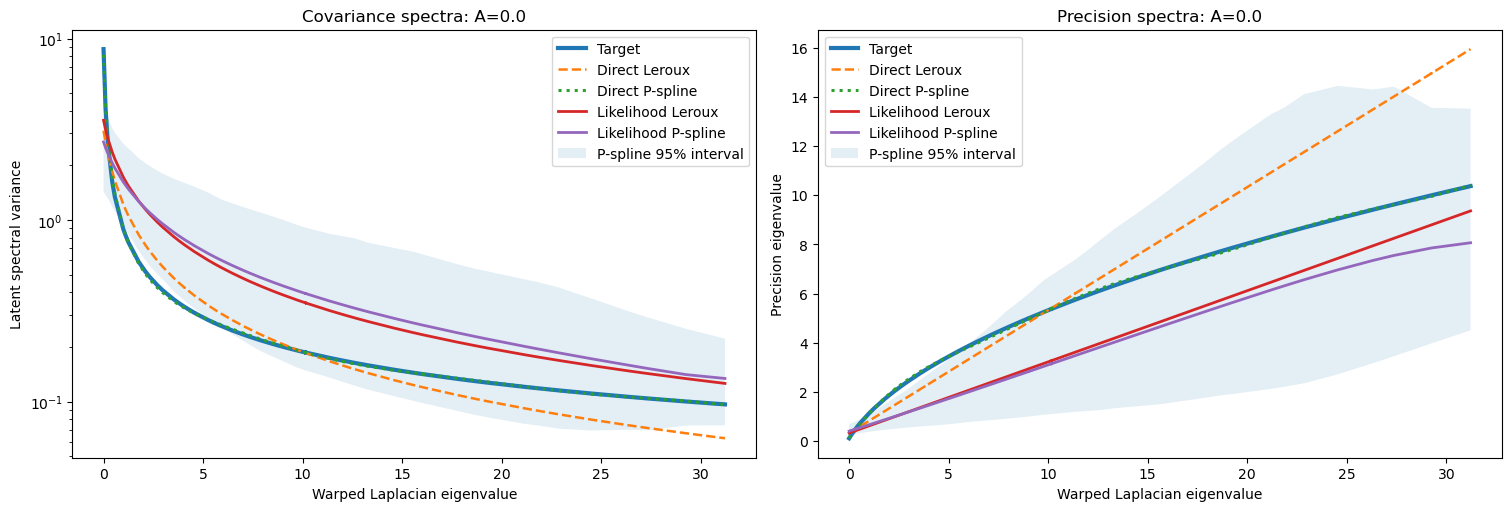

In [180]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_covariance[order],
    linewidth=3,
    label="Target",
)
axes[0].plot(
    lam_warp[order],
    F_direct_leroux[order],
    linestyle="--",
    linewidth=1.8,
    label="Direct Leroux",
)
axes[0].plot(
    lam_warp[order],
    F_direct_fit[order],
    linestyle=":",
    linewidth=2.2,
    label="Direct P-spline",
)
axes[0].plot(
    lam_warp[order],
    F_leroux_mean[order],
    linewidth=2,
    label="Likelihood Leroux",
)
axes[0].plot(
    lam_warp[order],
    F_pspline_mean[order],
    linewidth=2,
    label="Likelihood P-spline",
)
axes[0].fill_between(
    lam_warp[order],
    F_pspline_lower[order],
    F_pspline_upper[order],
    alpha=0.12,
    label="P-spline 95% interval",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Warped Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(
    f"Covariance spectra: A={AFFINE_SHIFT_A}"
)
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target",
)
axes[1].plot(
    lam_warp[order],
    q_direct_leroux[order],
    linestyle="--",
    linewidth=1.8,
    label="Direct Leroux",
)
axes[1].plot(
    lam_warp[order],
    q_direct_fit[order],
    linestyle=":",
    linewidth=2.2,
    label="Direct P-spline",
)
axes[1].plot(
    lam_warp[order],
    q_leroux_mean[order],
    linewidth=2,
    label="Likelihood Leroux",
)
axes[1].plot(
    lam_warp[order],
    q_pspline_mean[order],
    linewidth=2,
    label="Likelihood P-spline",
)
axes[1].fill_between(
    lam_warp[order],
    q_pspline_lower[order],
    q_pspline_upper[order],
    alpha=0.12,
    label="P-spline 95% interval",
)
axes[1].set_xlabel("Warped Laplacian eigenvalue")
axes[1].set_ylabel("Precision eigenvalue")
axes[1].set_title(
    f"Precision spectra: A={AFFINE_SHIFT_A}"
)
axes[1].legend()

plt.show()


## 12. Leroux precision versus P-spline affine baseline and nonlinear correction

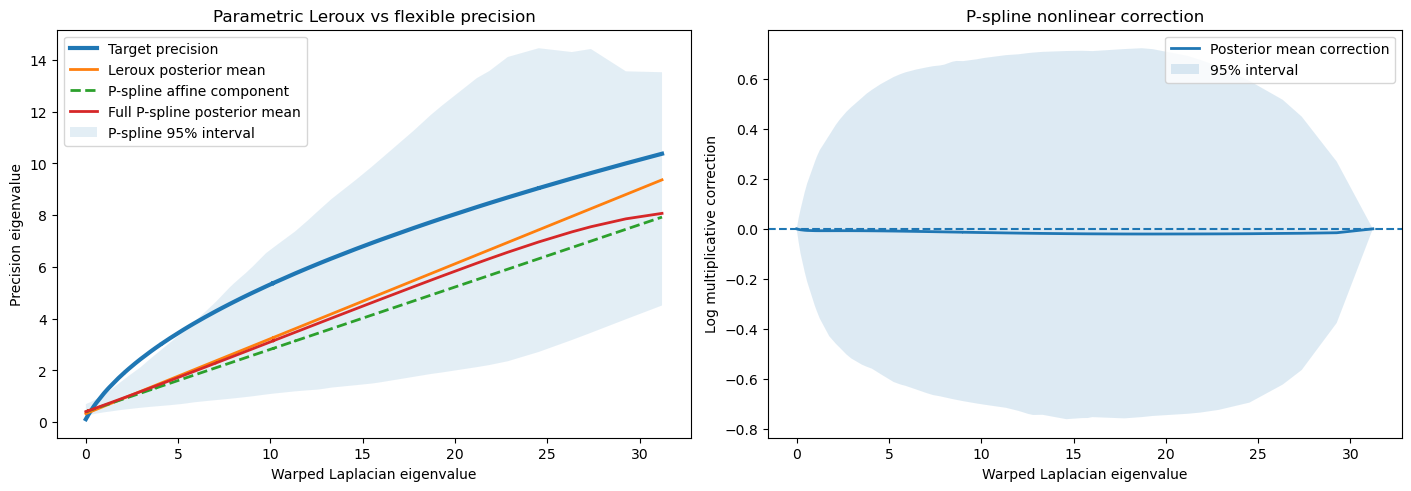

In [181]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)

axes[0].plot(
    lam_warp[order],
    q_leroux_mean[order],
    linewidth=2,
    label="Leroux posterior mean",
)

axes[0].plot(
    lam_warp[order],
    q_pspline_affine_mean[order],
    linestyle="--",
    linewidth=2,
    label="P-spline affine component",
)

axes[0].plot(
    lam_warp[order],
    q_pspline_mean[order],
    linewidth=2,
    label="Full P-spline posterior mean",
)

axes[0].fill_between(
    lam_warp[order],
    q_pspline_lower[order],
    q_pspline_upper[order],
    alpha=0.12,
    label="P-spline 95% interval",
)

axes[0].set_xlabel(
    "Warped Laplacian eigenvalue"
)
axes[0].set_ylabel("Precision eigenvalue")
axes[0].set_title(
    "Parametric Leroux vs flexible precision"
)
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    vi_log_correction_mean[order],
    linewidth=2,
    label="Posterior mean correction",
)

axes[1].fill_between(
    lam_warp[order],
    vi_log_correction_lower[order],
    vi_log_correction_upper[order],
    alpha=0.15,
    label="95% interval",
)

axes[1].axhline(
    0.0,
    linestyle="--",
)

axes[1].set_xlabel(
    "Warped Laplacian eigenvalue"
)
axes[1].set_ylabel(
    "Log multiplicative correction"
)
axes[1].set_title(
    "P-spline nonlinear correction"
)
axes[1].legend()

plt.show()


In [182]:
endpoint_table = pd.DataFrame(
    [
        {
            "model": "Target",
            "q_left_mean": target_precision[left],
            "q_left_lower": np.nan,
            "q_left_upper": np.nan,
            "q_right_mean": target_precision[right],
            "q_right_lower": np.nan,
            "q_right_upper": np.nan,
        },
        {
            "model": "Likelihood Leroux",
            "q_left_mean": q_leroux_mean[left],
            "q_left_lower": q_leroux_lower[left],
            "q_left_upper": q_leroux_upper[left],
            "q_right_mean": q_leroux_mean[right],
            "q_right_lower": q_leroux_lower[right],
            "q_right_upper": q_leroux_upper[right],
        },
        {
            "model": "Likelihood P-spline",
            "q_left_mean": q_pspline_mean[left],
            "q_left_lower": q_pspline_lower[left],
            "q_left_upper": q_pspline_upper[left],
            "q_right_mean": q_pspline_mean[right],
            "q_right_lower": q_pspline_lower[right],
            "q_right_upper": q_pspline_upper[right],
        },
    ]
)

display(endpoint_table)

print(
    "Target inside Leroux right-endpoint interval:",
    bool(
        q_leroux_lower[right]
        <= target_precision[right]
        <= q_leroux_upper[right]
    ),
)

print(
    "Target inside P-spline right-endpoint interval:",
    bool(
        q_pspline_lower[right]
        <= target_precision[right]
        <= q_pspline_upper[right]
    ),
)


,model,q_left_mean,q_left_lower,q_left_upper,q_right_mean,q_right_lower,q_right_upper
0,Target,0.114286,NaN,NaN,10.371269,NaN,NaN
1,Likelihood Leroux,0.329346,0.132794,0.617330,9.362770,3.557577,17.456456
2,Likelihood P-spline,0.406625,0.218122,0.693582,8.066948,4.506269,13.521285


Target inside Leroux right-endpoint interval: True
Target inside P-spline right-endpoint interval: True


## 13. Held-out latent-field reconstruction

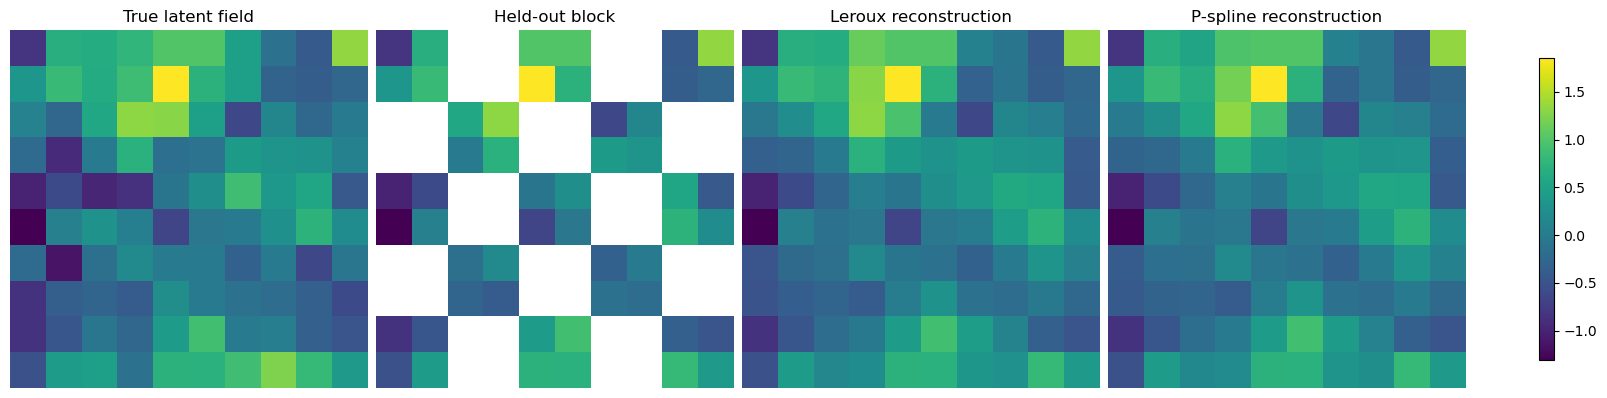

In [183]:
masked = eta_true.copy()
masked[test_mask] = np.nan

leroux_completed = eta_true.copy()
leroux_completed[test_mask] = (
    leroux_prediction_mean
)

pspline_completed = eta_true.copy()
pspline_completed[test_mask] = (
    pspline_prediction_mean
)

fields = [
    eta_true.reshape(N_ROWS, N_COLS),
    masked.reshape(N_ROWS, N_COLS),
    leroux_completed.reshape(N_ROWS, N_COLS),
    pspline_completed.reshape(N_ROWS, N_COLS),
]

titles = [
    "True latent field",
    "Held-out block",
    "Leroux reconstruction",
    "P-spline reconstruction",
]

finite_values = np.concatenate(
    [
        field[np.isfinite(field)]
        for field in fields
    ]
)

vmin = finite_values.min()
vmax = finite_values.max()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, field, title in zip(
    axes,
    fields,
    titles,
):
    image = ax.imshow(
        field,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
)

plt.show()


## 14. Optimization diagnostics

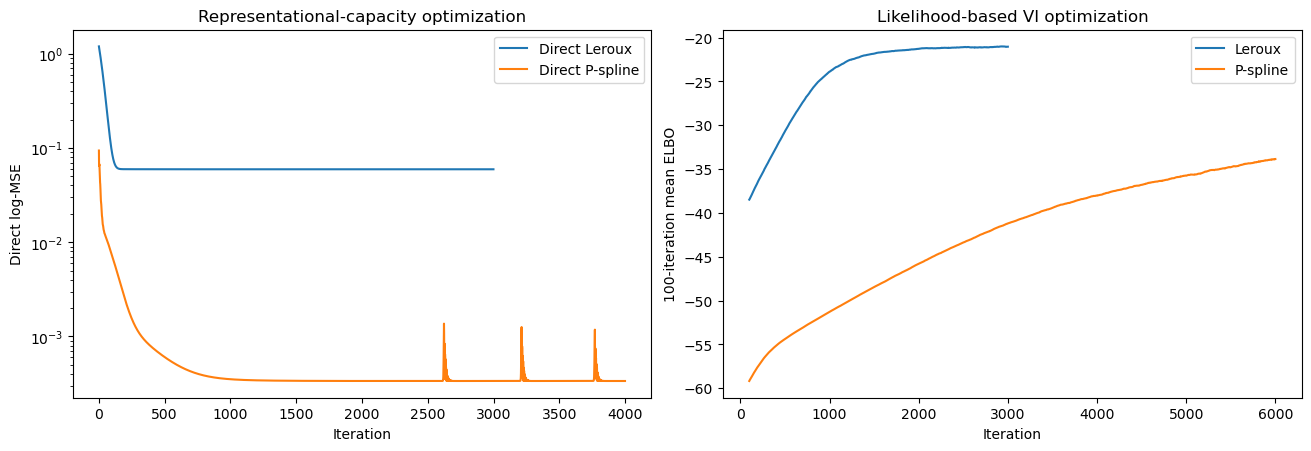

In [184]:
leroux_history = np.asarray(
    leroux_result["history"]
)
pspline_history = np.asarray(
    pspline_result["history"]
)

leroux_smoothed = (
    pd.Series(leroux_history)
    .rolling(100)
    .mean()
)
pspline_smoothed = (
    pd.Series(pspline_history)
    .rolling(100)
    .mean()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.4),
    constrained_layout=True,
)

axes[0].plot(
    direct_leroux_loss_history,
    label="Direct Leroux",
)
axes[0].plot(
    direct_pspline_loss_history,
    label="Direct P-spline",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Direct log-MSE")
axes[0].set_title(
    "Representational-capacity optimization"
)
axes[0].legend()

axes[1].plot(
    leroux_smoothed,
    label="Leroux",
)
axes[1].plot(
    pspline_smoothed,
    label="P-spline",
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(
    "100-iteration mean ELBO"
)
axes[1].set_title(
    "Likelihood-based VI optimization"
)
axes[1].legend()

plt.show()


## How to interpret the results

The notebook compares Leroux CAR and adaptive precision P-spline SDM-CAR under the **same deliberately warped spectral operator**.

The data are always generated from a true Leroux model on the true rook-lattice Laplacian,

$$
L_{\mathrm{true}}
=
U\Lambda U^\top,
$$

with true precision spectrum

$$
q_{\mathrm{true}}(\lambda)
=
\frac{(1-\rho_0)+\rho_0\lambda}{\tau_0^2}.
$$

The fitted models retain the true eigenvectors,

$$
U_{\mathrm{warp}} = U_{\mathrm{true}},
$$

but receive warped eigenvalues

$$
\mu_1 = 0,
$$

and, for positive modes,

$$
\mu_i
=
A
+
B\lambda_i
+
C\frac{\lambda_i^2}{\lambda_{\max}},
\qquad i\ge2.
$$

This lets us increase operator misspecification in a controlled way while keeping the eigenvector basis fixed.

### Correctly specified case

When

$$
A=0,\qquad B=1,\qquad C=0,
$$

we have

$$
\mu_i=\lambda_i,
$$

so the fitted operator is correct.

The target precision is exactly Leroux-affine in the supplied eigenvalues. Therefore:

- the direct Leroux fit should be essentially exact;
- the direct P-spline fit should also be essentially exact;
- likelihood-based Leroux should provide a strong baseline;
- the adaptive P-spline should require little nonlinear curvature;
- any substantial P-spline correction in this setting would indicate either finite-sample variability, regularization effects, or optimization error.

### Affine misspecification: $C=0$

When

$$
C=0,
$$

the positive modes satisfy

$$
\mu_i=A+B\lambda_i.
$$

For $B=1$, the positive-mode Leroux compatibility threshold is

$$
A_{\mathrm{critical}}
=
\frac{1-\rho_0}{\rho_0}.
$$

For

$$
0<A<A_{\mathrm{critical}},
$$

the transformed positive-mode target can still be represented by a Leroux precision function in principle.

For

$$
A>A_{\mathrm{critical}},
$$

an ordinary Leroux model on the warped positive eigenvalues cannot reproduce the target precision exactly because the required affine precision intercept falls outside the admissible Leroux family.

This gives a controlled transition from correct specification to parametric family misspecification.

### Nonlinear misspecification: $C>0$

When

$$
A=0,\qquad B=1,\qquad C>0,
$$

the positive eigenvalues satisfy

$$
\mu
=
\lambda
+
C\frac{\lambda^2}{\lambda_{\max}}.
$$

The target precision is still affine in the true eigenvalue $\lambda$,

$$
q_{\mathrm{true}}(\lambda)
=
\frac{(1-\rho_0)+\rho_0\lambda}{\tau_0^2},
$$

but it is no longer affine when expressed as a function of the warped eigenvalue $\mu$.

Thus,

$$
q_{\mathrm{target}}(\mu)
=
q_{\mathrm{true}}\!\left(\lambda(\mu)\right)
$$

is nonlinear for $C>0$.

A Leroux model fitted to the warped operator is restricted to

$$
q_{\mathrm{Leroux}}(\mu)
=
\frac{(1-\rho)+\rho\mu}{\tau^2},
$$

which is affine in $\mu$.

Therefore, under nonlinear warping, the Leroux model is structurally unable to reproduce the exact target precision curve, whereas the adaptive precision P-spline can introduce local curvature through its second-difference parameters and hierarchical local-scale prior. :contentReference[oaicite:0]{index=0}

### What to compare

1. **Direct spectrum error.**

   The direct fits are given the known target spectrum and therefore measure only **representational capacity**.

   If

   $$
   \operatorname{RMSE}_{\log q,\mathrm{P\text{-}spline}}
   \ll
   \operatorname{RMSE}_{\log q,\mathrm{Leroux}},
   $$

   then the flexible model family has the capacity required to represent the misspecified target.

2. **Likelihood spectrum error.**

   The likelihood-based fits use only the noisy observed spatial data.

   If the direct P-spline is nearly exact but the likelihood P-spline does not fully recover the target, then the limitation is not model-family capacity. Instead, it reflects finite-sample information, regularization, variational approximation, or optimization.

3. **Held-out latent-field RMSE.**

   Define the predictive improvement as

   $$
   G
   =
   \operatorname{RMSE}_{\eta,\mathrm{Leroux}}
   -
   \operatorname{RMSE}_{\eta,\mathrm{P\text{-}spline}}.
   $$

   Then

   $$
   G>0
   $$

   favors the P-spline, while

   $$
   G<0
   $$

   favors Leroux.

   This is the main test of whether improved spectral flexibility translates into improved spatial prediction.

4. **Affine baseline versus nonlinear correction.**

   The P-spline contains a global affine precision component together with a nonlinear residual correction.

   The affine component shows the broad CAR-like trend, while the residual indicates where the flexible model bends away from that baseline.

   Under correct specification, the nonlinear correction should remain small.

   As operator misspecification becomes more severe, successful adaptation should appear as increasingly structured curvature in the P-spline precision function.

5. **Curvature and shrinkage.**

   The second-difference parameters,

   $$
   d_{2,j},
   $$

   quantify local departures from the affine baseline.

   The adaptive model places a local-scale shrinkage prior on these curvature parameters, so the model is encouraged to remain approximately affine unless the likelihood provides evidence for nonlinear structure. :contentReference[oaicite:1]{index=1}

   Useful diagnostics include

   $$
   \|d_2\|_2,
   $$

   the maximum absolute second difference, the residual correction, and the learned local scales.

6. **Posterior uncertainty.**

   Do not evaluate spectral recovery only from a plug-in curve evaluated at the variational means.

   Posterior summaries are obtained by drawing filter parameters from the variational posterior and calculating

   $$
   q^{(m)}(\mu),
   \qquad m=1,\ldots,M.
   $$

   The posterior mean precision is approximated by

   $$
   \mathbb{E}_q[q(\mu)]
   \approx
   \frac{1}{M}
   \sum_{m=1}^{M}
   q^{(m)}(\mu),
   $$

   together with pointwise 95\% posterior intervals.

### Controlled difficulty sequences

For the original affine experiment, vary only

```python
AFFINE_SHIFT_A = 0.00
AFFINE_SHIFT_A = 0.05
AFFINE_SHIFT_A = 0.10
AFFINE_SHIFT_A = 0.25
AFFINE_SHIFT_A = 0.50
AFFINE_SHIFT_A = 1.00